# import libraries

In [1]:
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from PIL import Image
import torchvision.transforms.v2 as transforms
import torchvision.models as models
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim

# read data

In [4]:
def read_images_from_directory(directory):
    image_files = []
    labels = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.jpg') or file.endswith('.png'):
                image_files.append(os.path.join(root, file))
                labels.append(os.path.basename(root))
    return image_files, labels

In [5]:
dataset_path = '/kaggle/input/datasets/reihanev/dl-hw2/HW2_Dataset'


if os.path.isdir(dataset_path):
    extracted_directory = dataset_path
elif dataset_path.endswith('.zip'):
    with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
        zip_ref.extractall(path='extracted_data')
    extracted_directory = 'extracted_data'


train_images, train_labels = read_images_from_directory(os.path.join(extracted_directory, 'Train'))
test_images, test_labels = read_images_from_directory(os.path.join(extracted_directory, 'Test'))

# train validation split

In [6]:
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.3)

In [7]:
print(f'Number of training data before augmentation: {len(train_images)}')
print(f'Number of validation data before augmentation: {len(val_images)}')
print(f'Number of testing data before augmentation: {len(test_images)}')

Number of training data before augmentation: 491
Number of validation data before augmentation: 211
Number of testing data before augmentation: 100


# data augmentation

In [8]:
flip_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

rotation_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


zooming_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(size=(224,224), scale=(0.75, 1.25)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [9]:
class custom_datatset(Dataset):
    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform

        self.class_to_idx = {'Cats': 0, 'Dogs': 1}  # Define your classes
        self.labels = [self.class_to_idx[label] for label in labels]

    def __len__(self):
        return(len(self.images))

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB') 
        image = self.transform(image)
        return image, label

In [10]:
flip_dataset = custom_datatset(train_images, train_labels, flip_aug)
rotated_dataset = custom_datatset(train_images, train_labels, rotation_aug)
zoomed_dataset = custom_datatset(train_images, train_labels, zooming_aug)

In [11]:
preprocessing = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [12]:
train_dataset = custom_datatset(train_images, train_labels, preprocessing)
val_dataset = custom_datatset(val_images, val_labels, preprocessing)
test_dataset = custom_datatset(test_images, test_labels, preprocessing)

In [13]:
aug_train_dataset = ConcatDataset([flip_dataset, rotated_dataset, zoomed_dataset, train_dataset])

In [14]:
print(f'Number of training data after augmentation: {len(aug_train_dataset)}')
print(f'Number of validation data after augmentation: {len(val_dataset)}')
print(f'Number of testing data after augmentation: {len(test_dataset)}')

Number of training data after augmentation: 1964
Number of validation data after augmentation: 211
Number of testing data after augmentation: 100


In [15]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
aug_train_loader = DataLoader(aug_train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# load models

In [16]:
resnet50 = models.resnet50(pretrained=True)
vgg16 = models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 217MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 193MB/s] 


In [13]:
num_features = vgg16.classifier[6].in_features  
vgg16.classifier[6] = nn.Linear(num_features, 2) 

for name, param in vgg16.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

# train and test functions

In [18]:
def traing_func(model, train_loader, val_loader):
    
    num_epoch = 50 
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)  
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=0.002)
    
    train_acc = []
    val_acc = []

    train_loss = []
    val_loss = []

    for i in range(num_epoch):
        model.train()
        
        running_loss = 0.0
        correct_pred = 0
        total_samples = 0

        for image, label in train_loader:
            image = image.to(device)
            label = label.to(device)
            output = model(image)

            loss = criterion(output, label)
        
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Statistics
            running_loss += loss.item() * image.size(0)

            # ✅ FIX: Use softmax + argmax for multi-class
            probs = torch.softmax(output, dim=1)  # Shape: (batch_size, 2)
            _, preds = torch.max(probs, 1)        # Shape: (batch_size,)
            
            total_samples += label.size(0)
            correct_pred += (preds == label).sum().item()

        loss = running_loss / total_samples
        acc = correct_pred / total_samples * 100

        print(f'Epoch {i+1}: Training Loss: {loss:.4f}, Training Accuracy: {acc:.2f}%')
        train_acc.append(acc)
        train_loss.append(loss)

        # -------- VALIDATION --------
        model.eval()
        val_running_loss = 0.0
        val_correct_pred = 0
        val_total_samples = 0
    
        with torch.no_grad():
            for image, label in val_loader:
                image = image.to(device)  
                label = label.to(device)
    
                output = model(image)
                loss = criterion(output, label)
                
                val_running_loss += loss.item() * image.size(0)
    
                probs = torch.softmax(output, dim=1)
                _, preds = torch.max(probs, 1)

                val_total_samples += label.size(0)
                val_correct_pred += (preds == label).sum().item()
    
        val_loss_epoch = val_running_loss / val_total_samples
        val_acc_epoch = val_correct_pred / val_total_samples * 100

        val_acc.append(val_acc_epoch)
        val_loss.append(val_loss_epoch)

        print(f'Validation Loss: {val_loss_epoch:.4f}, Validation Accuracy: {val_acc_epoch:.2f}%')
        print('-' * 60)
    
    # Plot results

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(train_loss) + 1), train_loss, label='Train')
    plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(train_acc) + 1), train_acc, label='Train')
    plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Validation Subset Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [19]:
def test_func(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for image, label in test_loader:
            image = image.to(device)
            label = label.to(device)

            output = model(image)
            probs = torch.softmax(output, dim=1)
            _, preds = torch.max(probs, 1)

            total += label.size(0)
            correct += (preds == label).sum().item()
            
    print('Accuracy on test set: {}%'.format(100 * correct / total))

# training resnet50

## training resnet classifier on original data

In [24]:
resnet50 = models.resnet50(pretrained=True)

num_features = resnet50.fc.in_features  
resnet50.fc = nn.Linear(num_features, 2) 

for name, param in resnet50.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False

Epoch 1: Training Loss: 1.0273, Training Accuracy: 83.50%
Validation Loss: 0.1610, Validation Accuracy: 97.63%
------------------------------------------------------------
Epoch 2: Training Loss: 0.3616, Training Accuracy: 96.13%
Validation Loss: 0.2047, Validation Accuracy: 97.16%
------------------------------------------------------------
Epoch 3: Training Loss: 0.4640, Training Accuracy: 95.72%
Validation Loss: 0.3282, Validation Accuracy: 96.21%
------------------------------------------------------------
Epoch 4: Training Loss: 0.1320, Training Accuracy: 98.78%
Validation Loss: 0.3580, Validation Accuracy: 96.21%
------------------------------------------------------------
Epoch 5: Training Loss: 0.3937, Training Accuracy: 96.54%
Validation Loss: 0.2841, Validation Accuracy: 96.68%
------------------------------------------------------------
Epoch 6: Training Loss: 0.1945, Training Accuracy: 98.37%
Validation Loss: 0.2557, Validation Accuracy: 96.68%
-----------------------------

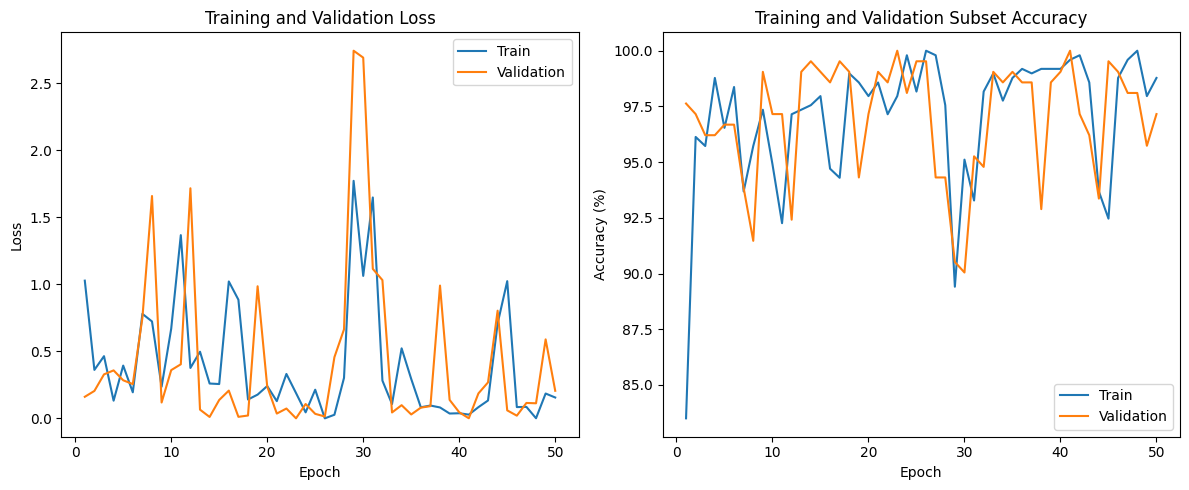

In [25]:
traing_func(resnet50, train_loader, val_loader)

In [26]:
test_func(resnet50, test_loader)

Accuracy on test set: 95.0%


## training last conv block of resnet on original data

Epoch 1: Training Loss: 15.0638, Training Accuracy: 80.04%
Validation Loss: 3639.7991, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 2: Training Loss: 3.6109, Training Accuracy: 81.87%
Validation Loss: 23.2632, Validation Accuracy: 79.15%
------------------------------------------------------------
Epoch 3: Training Loss: 2.7976, Training Accuracy: 89.41%
Validation Loss: 1.4423, Validation Accuracy: 91.94%
------------------------------------------------------------
Epoch 4: Training Loss: 0.6964, Training Accuracy: 95.11%
Validation Loss: 0.5372, Validation Accuracy: 92.89%
------------------------------------------------------------
Epoch 5: Training Loss: 0.8205, Training Accuracy: 94.91%
Validation Loss: 0.6860, Validation Accuracy: 94.31%
------------------------------------------------------------
Epoch 6: Training Loss: 0.7136, Training Accuracy: 94.30%
Validation Loss: 1.5560, Validation Accuracy: 88.15%
------------------------

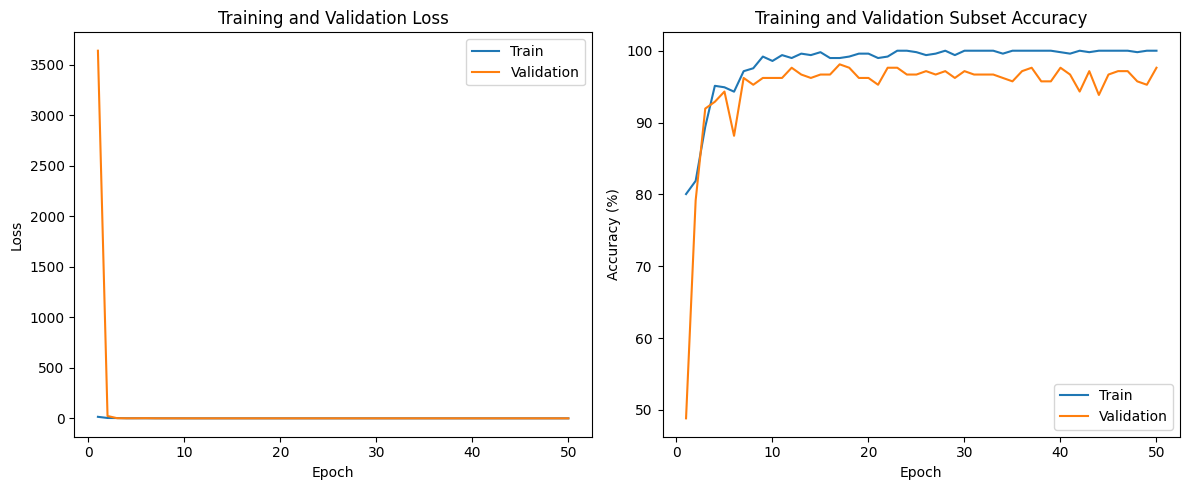

In [27]:
for param in resnet50.layer4.parameters():
        param.requires_grad = True

traing_func(resnet50, train_loader, val_loader)

In [28]:
test_func(resnet50, test_loader)

Accuracy on test set: 98.0%


## training resnet50 classifier on augmented data

Epoch 1: Training Loss: 1.7088, Training Accuracy: 89.61%
Validation Loss: 0.0875, Validation Accuracy: 98.10%
------------------------------------------------------------
Epoch 2: Training Loss: 0.4611, Training Accuracy: 97.05%
Validation Loss: 1.0278, Validation Accuracy: 93.36%
------------------------------------------------------------
Epoch 3: Training Loss: 0.3668, Training Accuracy: 97.51%
Validation Loss: 0.0199, Validation Accuracy: 99.53%
------------------------------------------------------------
Epoch 4: Training Loss: 0.5399, Training Accuracy: 96.49%
Validation Loss: 0.0399, Validation Accuracy: 99.05%
------------------------------------------------------------
Epoch 5: Training Loss: 0.4656, Training Accuracy: 96.95%
Validation Loss: 0.0321, Validation Accuracy: 99.05%
------------------------------------------------------------
Epoch 6: Training Loss: 1.4843, Training Accuracy: 92.57%
Validation Loss: 0.0449, Validation Accuracy: 99.53%
-----------------------------

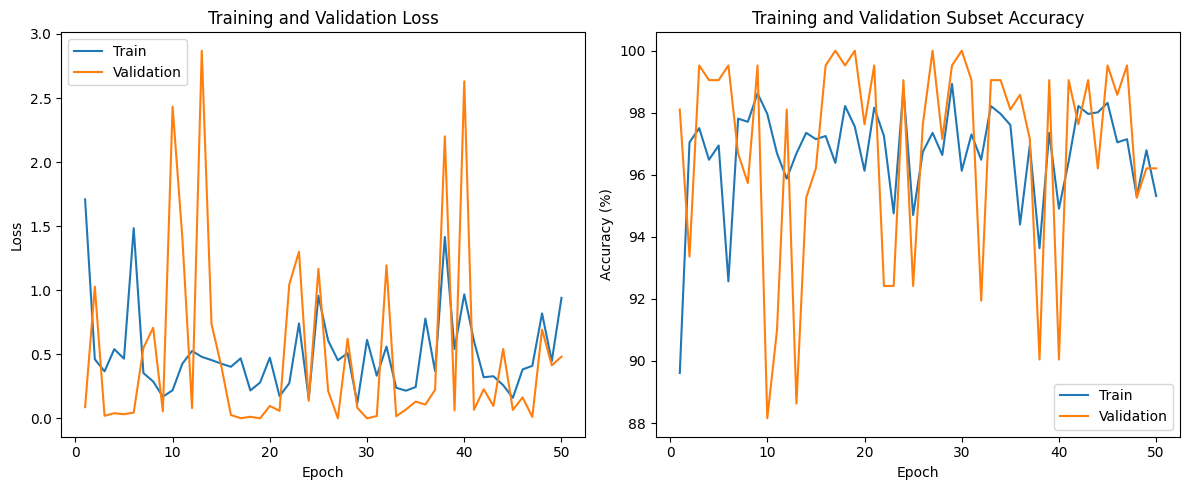

In [29]:
resnet50 = models.resnet50(pretrained=True)

num_features = resnet50.fc.in_features  
resnet50.fc = nn.Linear(num_features, 2) 

for name, param in resnet50.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False

traing_func(resnet50, aug_train_loader, val_loader)

In [30]:
test_func(resnet50, test_loader)

Accuracy on test set: 96.0%


## training last conv block of resnet50 on augmented data

Epoch 1: Training Loss: 6.6191, Training Accuracy: 83.30%
Validation Loss: 0.3820, Validation Accuracy: 91.94%
------------------------------------------------------------
Epoch 2: Training Loss: 0.1860, Training Accuracy: 94.60%
Validation Loss: 0.0539, Validation Accuracy: 96.68%
------------------------------------------------------------
Epoch 3: Training Loss: 0.1274, Training Accuracy: 95.42%
Validation Loss: 0.0650, Validation Accuracy: 96.21%
------------------------------------------------------------
Epoch 4: Training Loss: 0.0820, Training Accuracy: 96.54%
Validation Loss: 0.0810, Validation Accuracy: 97.63%
------------------------------------------------------------
Epoch 5: Training Loss: 0.0669, Training Accuracy: 97.61%
Validation Loss: 0.0550, Validation Accuracy: 97.63%
------------------------------------------------------------
Epoch 6: Training Loss: 0.0649, Training Accuracy: 97.45%
Validation Loss: 0.0603, Validation Accuracy: 97.63%
-----------------------------

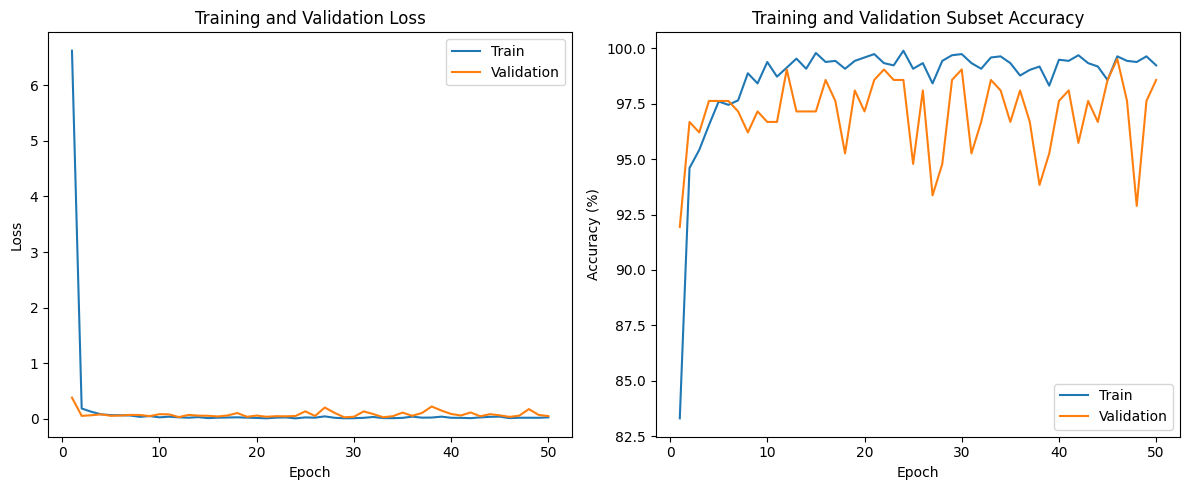

In [31]:
for param in resnet50.layer4.parameters():
        param.requires_grad = True

traing_func(resnet50, aug_train_loader, val_loader)

In [32]:
test_func(resnet50, test_loader)

Accuracy on test set: 98.0%


# training VGG19

## training vgg19 classifier on original data

In [33]:
vgg16 = models.vgg16(pretrained=True)

num_features = vgg16.classifier[6].in_features  
vgg16.classifier[6] = nn.Linear(num_features, 2) 

for name, param in vgg16.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

Epoch 1: Training Loss: 29063480519633576658993152.0000, Training Accuracy: 61.30%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 2: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 3: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 4: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 5: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 6: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
-------------------------------------

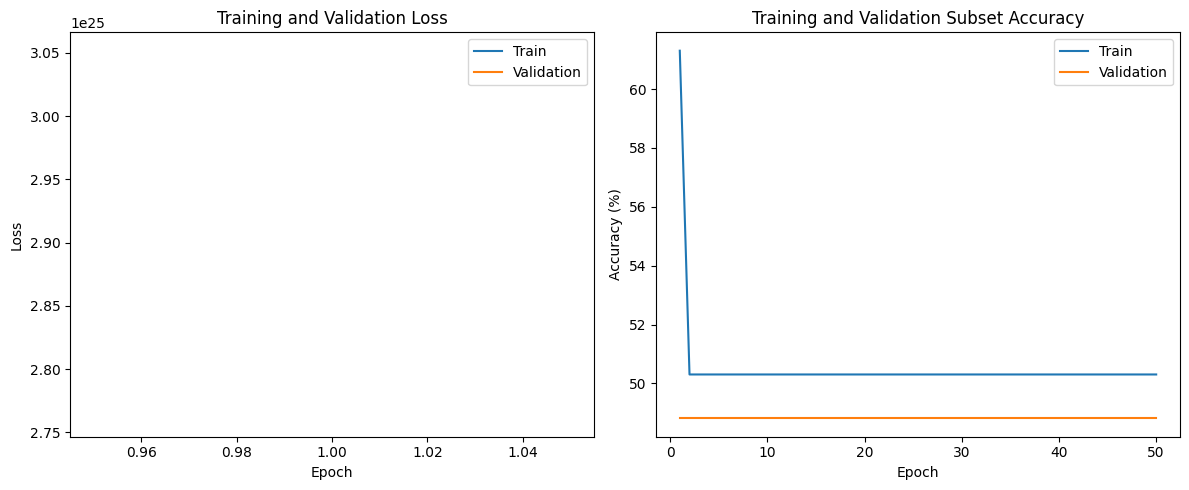

In [34]:
traing_func(vgg16, train_loader, val_loader)

In [35]:
test_func(vgg16, test_loader)

Accuracy on test set: 50.0%


## training last conv block of vgg19 on original data

Epoch 1: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 2: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 3: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 4: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 5: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 6: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoc

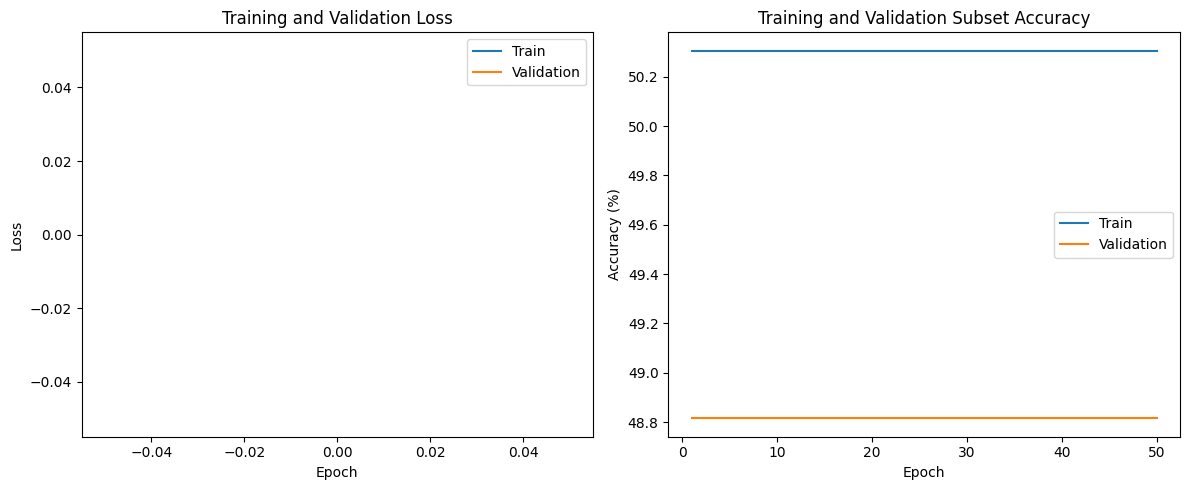

In [36]:
for param in vgg16.features[24:30].parameters():
        param.requires_grad = True

traing_func(vgg16, train_loader, val_loader)

In [37]:
test_func(vgg16, test_loader)

Accuracy on test set: 50.0%


## training vgg19 classifier on augmented data

In [38]:
vgg16 = models.vgg16(pretrained=True)

num_features = vgg16.classifier[6].in_features  
vgg16.classifier[6] = nn.Linear(num_features, 2) 

for name, param in vgg16.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

Epoch 1: Training Loss: nan, Training Accuracy: 53.82%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 2: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 3: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 4: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 5: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 6: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoc

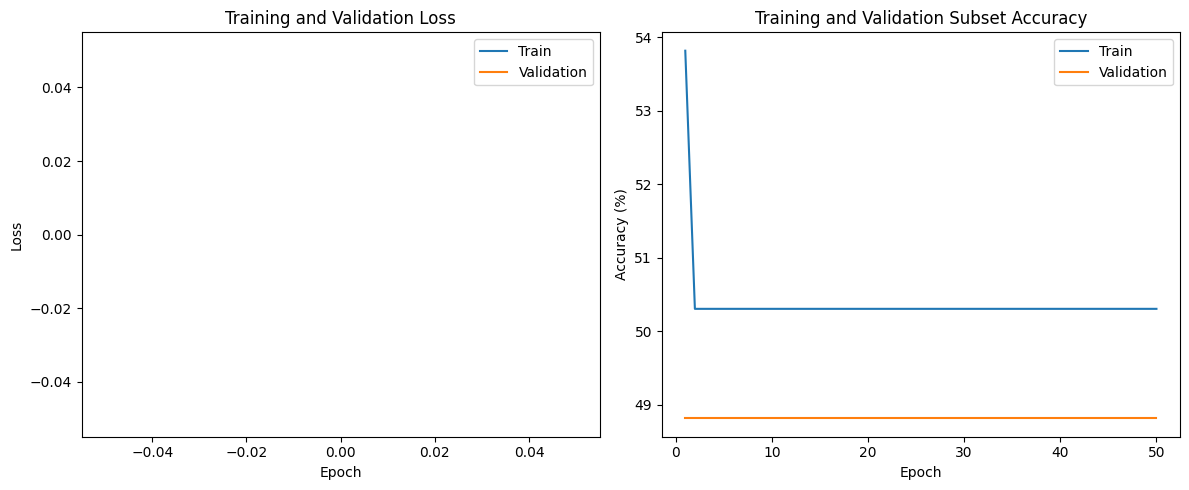

In [39]:
traing_func(vgg16, aug_train_loader, val_loader)

In [40]:
test_func(vgg16, test_loader)

Accuracy on test set: 50.0%


## training last conv block of vgg19 on augmented data

Epoch 1: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 2: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 3: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 4: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 5: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoch 6: Training Loss: nan, Training Accuracy: 50.31%
Validation Loss: nan, Validation Accuracy: 48.82%
------------------------------------------------------------
Epoc

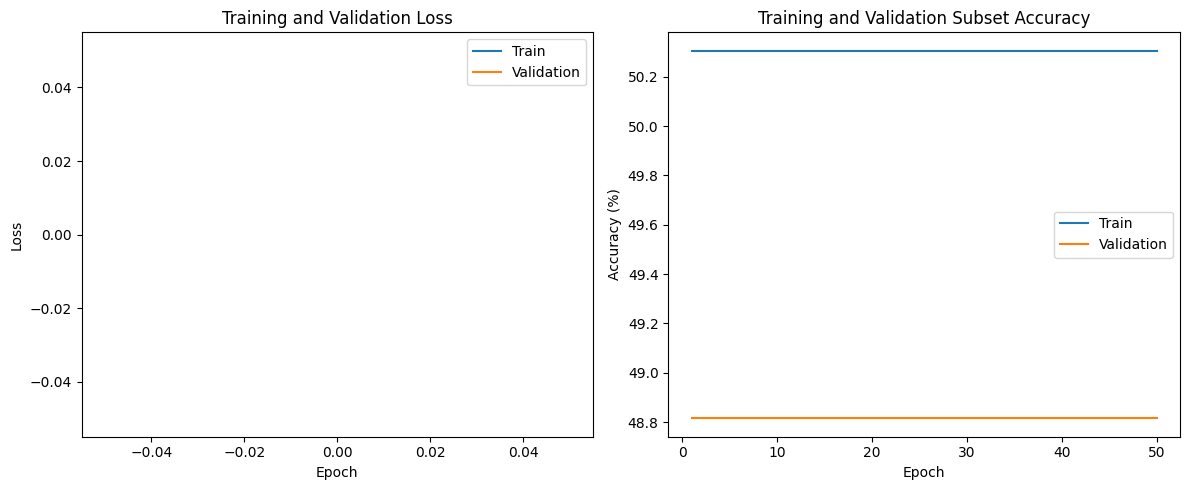

In [41]:
for param in vgg16.features[24:30].parameters():
        param.requires_grad = True

traing_func(vgg16, aug_train_loader, val_loader)

In [42]:
test_func(vgg16, test_loader)

Accuracy on test set: 50.0%
